In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('Penguin Species Prediction Dataset.csv')

df.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303g,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739,Male
4,Adelie,Dream,39.0,17.8,187.0,3607,Male
5,Adelie,Dream,41.6,17.4,189.0,3568,Female
6,Adelie,Dream,41.1,16.8,192.0,3967,Male
7,Gentoo,Biscoe,49.6,15.0,224.0,4742,Male
8,Chinstrap,Dream,55.7,18.1,193.0,4166g,Male
9,Gentoo,Biscoe,44.9,15.6,215.0,4688,Male


In [20]:
print("Before correction:\n")
df.dtypes

Before correction:



species                  str
island                   str
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g              str
sex                      str
dtype: object

In [21]:
df['body_mass_g'] = df['body_mass_g'].astype(str).str.replace('g', '', regex=False)
df['body_mass_g'] = pd.to_numeric(df['body_mass_g'], errors='coerce')

print("After correction:\n")
df.dtypes

After correction:



species                  str
island                   str
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

In [23]:
df_missing = df.copy()

print("Missing Values Before Handling:\n")
print(df_missing.isna().sum())

Missing Values Before Handling:

species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    11
body_mass_g          10
sex                  12
dtype: int64


In [27]:
df_removed = df_missing.dropna()

print("Original shape:", df_missing.shape)
print("Shape after dropping:", df_removed.shape)
print("\nMissing values in df_removed:")
print(df_removed.isna().sum())

Original shape: (1000, 7)
Shape after dropping: (948, 7)

Missing values in df_removed:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [30]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

df_mean = df_missing.copy()

for col in num_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

print("Missing values in df_mean:")
print(df_mean.isna().sum())

Missing values in df_mean:
species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm     0
body_mass_g           0
sex                  12
dtype: int64


In [32]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

df_median = df_missing.copy()

for col in num_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

print("Missing values after Median Imputation:")
print(df_median.isna().sum())

Missing values after Median Imputation:
species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm     0
body_mass_g           0
sex                  12
dtype: int64


In [33]:
mode_sex = df_median['sex'].mode()[0]
df_median['sex'] = df_median['sex'].fillna(mode_sex)

print("Missing values after Mode Imputation:")
print(df_median.isna().sum())

Missing values after Mode Imputation:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


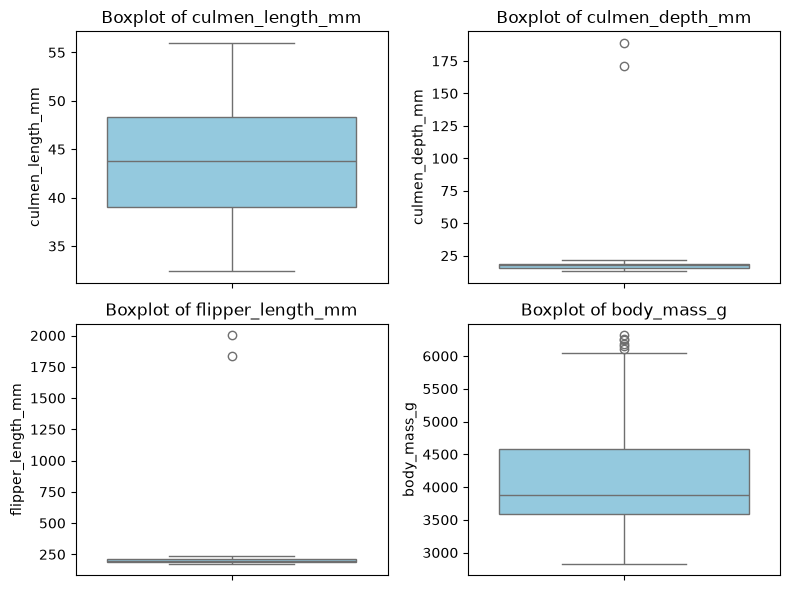

In [41]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Plot boxplot
plt.figure(figsize=(8, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_median[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [43]:
df_no_outliers = df_median.copy()

# Fix outliers
for col in num_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled using IQR Capping")

Outliers handled using IQR Capping


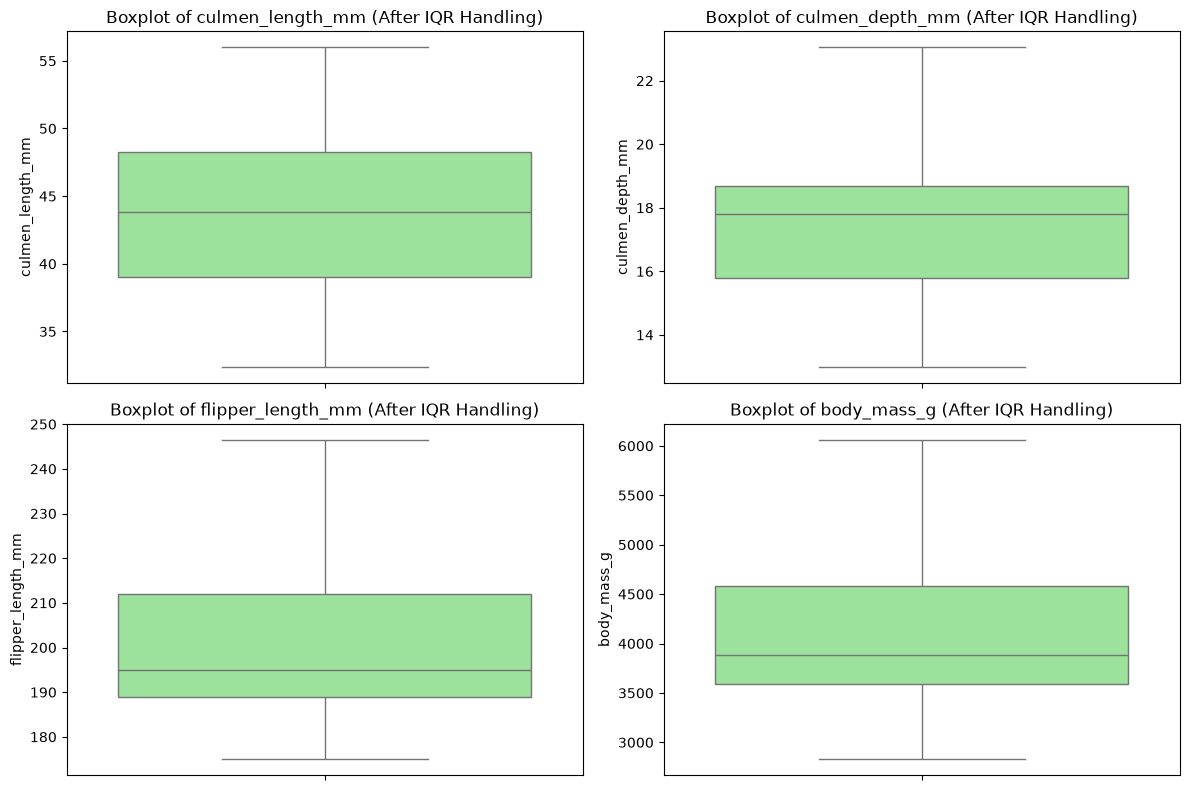

In [46]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_no_outliers[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (After IQR Handling)')

plt.tight_layout()
plt.show()

In [49]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max Normalization
df_minmax = df_no_outliers.copy()

min_max_scaler = MinMaxScaler()

df_minmax[num_cols] = min_max_scaler.fit_transform(df_minmax[num_cols])

print("Min-Max Normalization completed:\n")
print(df_minmax[num_cols].head())

Min-Max Normalization completed:

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0          0.368644         0.537313           0.279720     0.326834
1          0.745763         0.238806           0.587413     0.455896
2          0.745763         0.208955           0.629371     0.657382
3          0.690678         0.597015           0.293706     0.281337
4          0.279661         0.477612           0.167832     0.240483


In [50]:
from sklearn.preprocessing import StandardScaler

# Z-Score Normalization
df_zscore = df_no_outliers.copy()

std_scaler = StandardScaler()

df_zscore[num_cols] = std_scaler.fit_transform(df_zscore[num_cols])

print("Z-Score Normalization completed:\n")
print(df_zscore[num_cols].head())

Z-Score Normalization completed:

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0         -0.514629         0.587261          -0.323653    -0.306369
1          1.170754        -1.091108           1.334948     0.290025
2          1.170754        -1.258945           1.561121     1.221085
3          0.924574         0.922935          -0.248262    -0.516608
4         -0.912303         0.251588          -0.926781    -0.705395


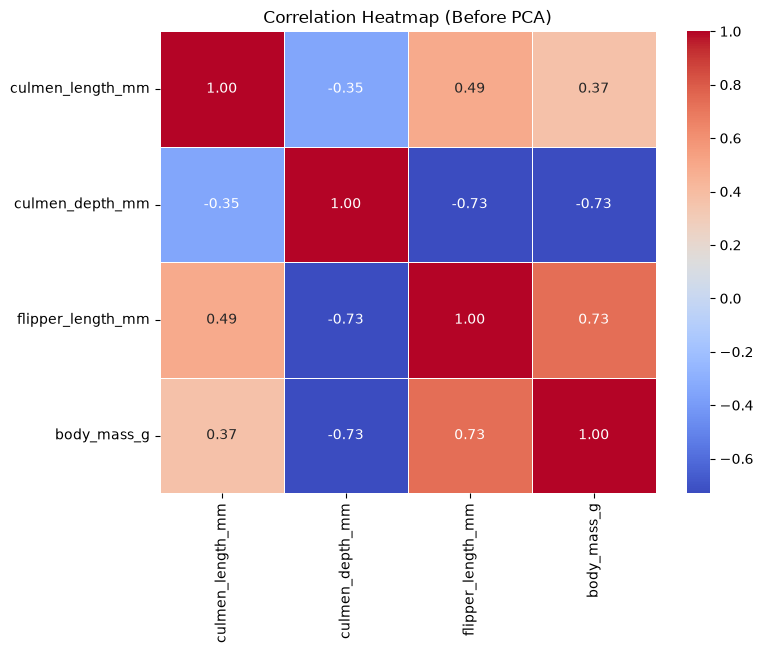

In [51]:
corr_matrix = df_zscore[num_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Before PCA)')
plt.show()

In [55]:
from sklearn.decomposition import PCA

X = df_zscore[num_cols]

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.684997   0.18580106]


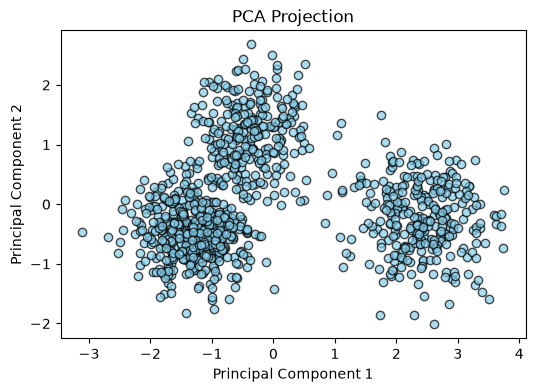

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.7, c='skyblue', edgecolors='k')
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()